# Portefeuille Core-Satellite  Notebook Principal

Ce notebook orchestre l'intégralité du pipeline quantitatif Core/Satellite :

| Étape | Module | Rôle |
|-------|--------|------|
| 1 | `core_pipeline` | Sélection des 3 ETF Core (Equity / Rates / Credit) sur 2019-2020 |
| 2 | `efficient_frontier_core` | Comparaison de 5 stratégies d'allocation Core (Markowitz) |
| 3 | `satellite_pipeline` | Filtrage 4 niveaux, 3 blocs, 9 meilleurs fonds |
| 4 | `fond_construction` | Calibration 2019-2020  Backtest 2021-2025, bêta contrôlé |
| 5 | `plots_report` | 25 graphiques (Core / Satellite / Comparaison / Total) |

**Fenêtres de temps :**
- Calibration (IS) : 01/01/2019  31/12/2020
- Backtest (OOS) : 01/01/2021  31/12/2025

**Architecture :** tout est en rendements journaliers (log), pas de conversion mensuelle.

In [ ]:
import os, sys
from pathlib import Path

# Se placer à la racine du projet
project_root = Path(r'C:\Users\Sebastian\Desktop\testing\Core_Satellite_Quant')
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print(f'Racine du projet : {Path.cwd()}')

Racine du projet : C:\Users\Sebastian\Desktop\testing\Core_Satellite_Quant


---
## Étape 1  Sélection des ETF Core

**Objectif :** identifier, parmi l'univers Bloomberg Cross-Asset, le meilleur ETF  
dans chacun des 3 thèmes (Equity / Rates / Credit) sur la fenêtre de calibration 2019-2020.

**Critères :** Sharpe IS, Max Drawdown IS, liquidité (volume), frais (TER).  
Les prix de clôture ajustés sont utilisés ; les rendements sont calculés en log journalier.

In [ ]:
from src.core_pipeline import main as core_main
core_main()

[1/7] Lecture Equity (nouveau fichier)...
  -> 59 ETFs uniques | 2010-01-04 à 2026-03-05
[2/7] Filtrage Equity : début ≤ 2019-01-01 | daily (gap ≤ 2.0) | expense ≤ 0.88 %
  -> 59 total | excl. date 22 | excl. fréq 0 | excl. frais 1
  -> ✓ 37 ETFs Equity retenus
[3/7] Lecture Rates / Credit (ancien fichier)...


TypeError: Invalid value '<DatetimeArray>
['2010-09-15 00:00:00', '2010-09-16 00:00:00', '2010-09-17 00:00:00',
 '2010-09-21 00:00:00', '2010-09-22 00:00:00', '2010-09-23 00:00:00',
 '2010-09-24 00:00:00', '2010-09-27 00:00:00', '2010-09-28 00:00:00',
 '2010-09-29 00:00:00',
 ...
 '2025-12-16 00:00:00', '2025-12-17 00:00:00', '2025-12-18 00:00:00',
 '2025-12-19 00:00:00', '2025-12-22 00:00:00', '2025-12-23 00:00:00',
 '2025-12-24 00:00:00', '2025-12-29 00:00:00', '2025-12-30 00:00:00',
 '2025-12-31 00:00:00']
Length: 3860, dtype: datetime64[s]' for dtype 'float64'

In [ ]:
core_df = pd.read_csv("outputs/Core_finaux.csv")
print("\u2705 3 ETF Core sélectionnés :")
display(core_df.style.hide(axis="index"))

✅ 3 ETF Core sélectionnés :


Ticker,Theme
DJSC LN Equity,Equity
CBE3 LN Equity,Rates
IEAC LN Equity,Credit


---
## Étape 2  Comparaison des stratégies d'allocation Core (Frontière Efficiente)

Cinq stratégies d'allocation sont comparées sur les 3 ETF Core sélectionnés :

| Stratégie | Description |
|-----------|-------------|
| **Max Sharpe (IS)** | Optimisation quadratique sur 2019-2020, poids fixés |
| **Min Variance (IS)** | Minimisation de la variance sur 2019-2020, poids fixés |
| **Equal Weight** | 1/3 par ETF, rééquilibré annuellement |
| **Risk Parity** | Pondération proportionnelle à 1/σ (volatilité inverse) |
| **Max Sharpe Rolling** | Fenêtre glissante 252j, rebalancement 63j (**stratégie retenue**) |

> Les stratégies sont calibrées sur 2019-2020 (IS) et évaluées sur 2021-2025 (OOS).

In [ ]:
from src.efficient_frontier_core import main as frontier_main
strategies, comp_df = frontier_main()

  COMPARAISON DES STRATÉGIES CORE (Markowitz daily)
  IS   : 2019-01-01 → 2020-12-31
  OOS  : 2021-01-01 → 2025-12-31

[1] Chargement des log-rendements journaliers des 3 ETF...
  ETFs : ['DJSC LN Equity', 'CBE3 LN Equity', 'IEAC LN Equity']
  Période : 2010-09-16 → 2026-03-05
  IS  : 514 obs | OOS : 1283 obs

[2] Simulation de la frontière (IS)...

[3] Optimisation des 4 stratégies statiques sur IS...
  Max Sharpe              w=[39.3%, 5.0%, 55.7%]  IS Sharpe=0.75  OOS Sharpe=0.05
  Min Variance            w=[5.0%, 70.0%, 25.0%]  IS Sharpe=0.59  OOS Sharpe=0.07
  Equal Weight            w=[33.3%, 33.3%, 33.3%]  IS Sharpe=0.74  OOS Sharpe=0.15
  Risk Parity             w=[4.0%, 84.1%, 11.9%]  IS Sharpe=0.54  OOS Sharpe=0.28

[4] Backtest rolling Max Sharpe (252j lookback, 63j rebal)...


c:\Users\33607\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\33607\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\33607\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


  Max Sharpe Rolling      (rolling)  OOS Sharpe=0.10

  TABLEAU COMPARATIF

Stratégie                    IS Ret   IS Vol   IS Sh  OOS Ret  OOS Vol  OOS Sh   OOS MDD
-------------------------------------------------------------------------------------
Max Sharpe                    7.2%     9.5%    0.75     0.4%     7.3%    0.05   -20.4%
Min Variance                  1.5%     2.6%    0.59     0.1%     2.2%    0.07    -9.0%
Equal Weight                  5.6%     7.6%    0.74     0.9%     5.9%    0.15   -16.4%
Risk Parity                   0.9%     1.7%    0.54     0.5%     1.8%    0.28    -7.1%
Max Sharpe Rolling            nan%     nan%     nan     0.9%     8.8%    0.10   -21.5%

  ★  Meilleure stratégie OOS (Sharpe) : Risk Parity

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\core_portfolio_comparison.csv

[5] Génération des figures...
  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\06_efficient_frontier_core.png
  -> C:\

In [ ]:
cols_is  = ['IS_ret_ann','IS_vol_ann','IS_sharpe']
cols_oos = ['OOS_ret_ann','OOS_vol_ann','OOS_sharpe','OOS_mdd']
fmt_pct  = {c: '{:.1%}' for c in cols_is + cols_oos if 'sharpe' not in c}
fmt_num  = {c: '{:.2f}' for c in cols_is + cols_oos if 'sharpe' in c}

print('=== IS (Calibration 2019-2020) ===')
display(comp_df[cols_is].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['IS_ret_ann','IS_sharpe'], color='lightgreen')
        .highlight_min(subset=['IS_vol_ann'], color='lightblue'))

print('\n=== OOS (Backtest 2021-2025) ===')
display(comp_df[cols_oos].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['OOS_ret_ann','OOS_sharpe'], color='lightgreen')
        .highlight_min(subset=['OOS_vol_ann','OOS_mdd'], color='lightblue'))

=== IS (Calibration 2019-2020) ===


,IS_ret_ann,IS_vol_ann,IS_sharpe
strategie,,,
Max Sharpe,7.2%,9.5%,0.75
Min Variance,1.5%,2.6%,0.59
Equal Weight,5.6%,7.6%,0.74
Risk Parity,0.9%,1.7%,0.54
Max Sharpe Rolling,nan%,nan%,nan



=== OOS (Backtest 2021-2025) ===


,OOS_ret_ann,OOS_vol_ann,OOS_sharpe,OOS_mdd
strategie,,,,
Max Sharpe,0.4%,7.3%,0.05,-20.4%
Min Variance,0.1%,2.2%,0.07,-9.0%
Equal Weight,0.9%,5.9%,0.15,-16.4%
Risk Parity,0.5%,1.8%,0.28,-7.1%
Max Sharpe Rolling,0.9%,8.8%,0.10,-21.5%


Frontière efficiente IS (2019-2020) + 5 stratégies


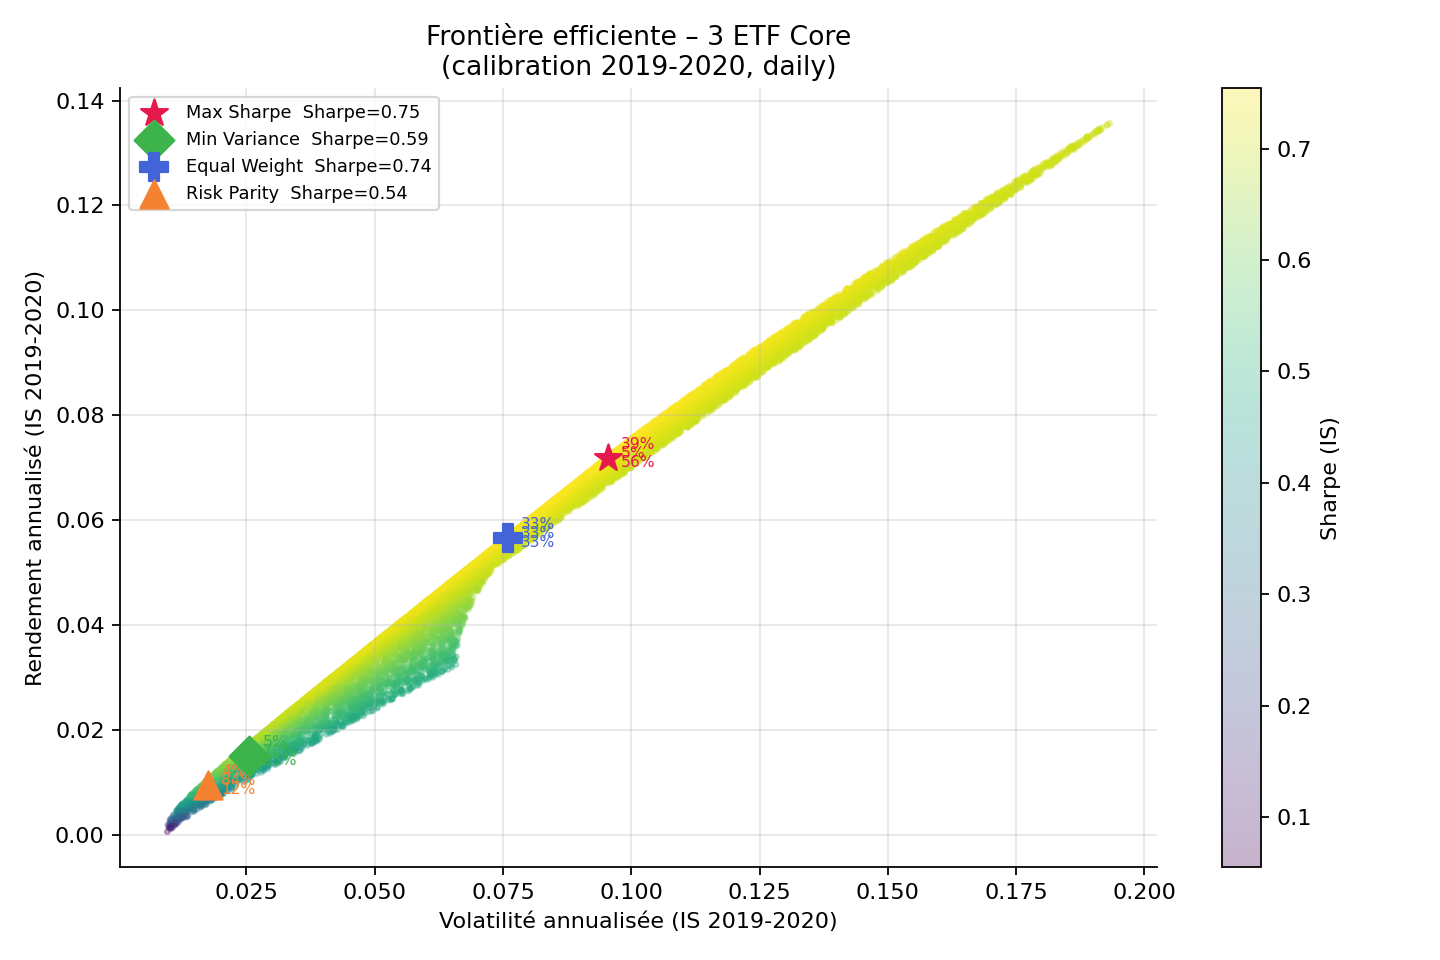

In [ ]:
print('Frontière efficiente IS (2019-2020) + 5 stratégies')
display(Image('outputs/figures/06_efficient_frontier_core.png'))

Performance cumulée OOS (2021-2025) des 5 stratégies


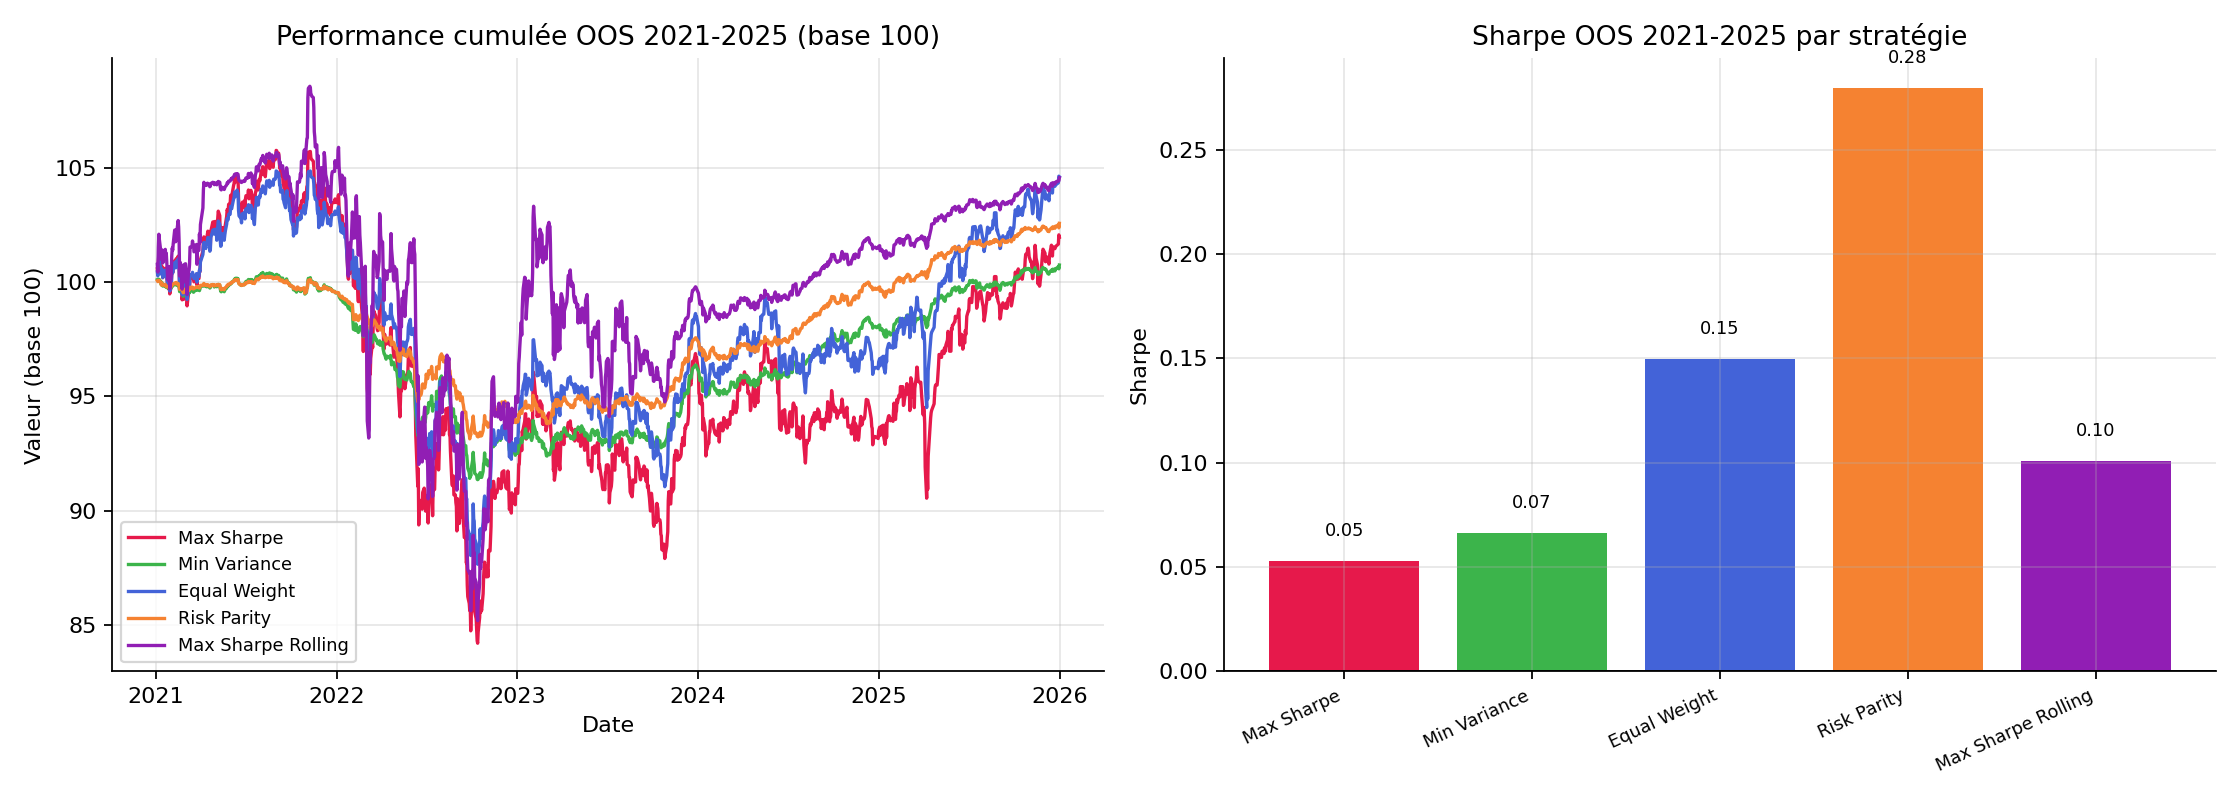

In [ ]:
print('Performance cumulée OOS (2021-2025) des 5 stratégies')
display(Image('outputs/figures/07_core_strategies_oos_perf.png'))

---
## Étape 3  Sélection des fonds Satellite

Filtrage en **4 niveaux** sur ~890 fonds alternatifs, organisés en 3 blocs :

- **Bloc 1 (Décorrélation)** : Long Volatilité, Tail Risk, Optionnel  convexité du portefeuille
- **Bloc 2 (Alpha contrôlé)** : Market Neutral, L/S Equity, CTA  alpha systématique, bêta  0.25
- **Bloc 3 (Macro)** : Commodities, ILS/Cat Bonds, ARP  moteurs orthogonaux au cycle

Les niveaux de filtrage :
1. **Structurel** : AUM  100M€, métriques complètes
2. **Frais & Vol** : plafonds adaptés par bloc
3. **Qualité quant** : Sharpe, Alpha, MDD
4. **Distribution** : Skewness, Kurtosis, diversification

In [ ]:
from src.satellite_pipeline import main as sat_main
sat_main()

  PIPELINE SATELLITE v2 – Filtrage & Sélection
  Fenêtre calib : 2019-01-01 → 2020-12-31

[1] Chargement des rendements Core...
    3717 obs. daily | 2011-09-07 → 2026-03-04
    Benchmark filtre beta : Core équipondéré (3 ETF sélectionnés via CSV)
    3969 obs. daily | 2010-09-17 → 2026-03-05

  Bloc 1 – Décorrélation / Convexité


  [données] 74 fonds avec prix ET info
  [métriques] Calcul sur calib 2019-01-01 → 2020-12-31...
  [beta init] Rolling 63j vs Core équipondéré...
  [Niv.Beta] |beta| <= 15% sur >= 80% jours     3 / 74
             3 fonds avec données suffisantes
  [Niv.0] AUM/Date/Devise/Excl.    2 / 74
  [Niv.1] Frais & Volatilité       2 / 2
  [Niv.2] Sharpe/Alpha/Drawdown    2 / 2
  [Niv.3] Skew/Kurt/Conc.          1 / 2

  [sélection] Bloc1 – 1 fonds retenus :
    #1  BFIST5I LX Equity             strat=Dérivés                       score=+0.000  β=+0.081  Sharpe=0.634

  [beta rolling 252j]...

  Bloc 2 – Alpha avec bêta contrôlé
  [données] 301 fonds avec prix ET info
  [métriques] Calcul sur calib 2019-01-01 → 2020-12-31...
  [beta init] Rolling 63j vs Core équipondéré...
  [Niv.Beta] |beta| <= 15% sur >= 80% jours    27 / 301
             27 fonds avec données suffisantes
  [Niv.0] AUM/Date/Devise/Excl.   20 / 301
  [Niv.1] Frais & Volatilité      17 / 20
  [Niv.2] Sharpe/Alpha/Drawdown   13 /

In [ ]:
sat_sel = pd.read_csv('outputs/satellite_selected.csv').set_index('ticker')
cols_show = [c for c in ['bloc','strategie','sharpe','alpha','mdd','aum','expense_pct'] if c in sat_sel.columns]
fmt = {c: ('{:.2f}' if c in ['sharpe','alpha'] else ('{:.1%}' if c in ['mdd','expense_pct'] else '{}'))
       for c in cols_show}
print(f'{len(sat_sel)} fonds satellite sélectionnés :')
display(sat_sel[cols_show].sort_values('bloc').style.format(fmt))

7 fonds satellite sélectionnés :


,bloc,strategie,expense_pct
ticker,,,
BFIST5I LX Equity,Bloc1,Dérivés,148.0%
MGFOIII ID Equity,Bloc2,Multi-stratégie,98.0%
LOTINAG IN Equity,Bloc2,Equity Hedge,106.0%
REARBVG IN Equity,Bloc2,Multi-stratégie,106.0%
JIRRX US Equity,Bloc3,Protégé contre l'inflation,109.0%
ROGMACS ID Equity,Bloc3,Titres adossés à des actifs,45.0%
MMLDX US Equity,Bloc3,Protégé contre l'inflation,0.0%


---
## Étape 4 — Construction et backtest du fonds Core-Satellite

**Principes :**
- **Poche Core (70-75 %)** : stratégie Max-Sharpe Rolling sur les 3 ETF
- **Poche Satellite (25-30 %)** : allocation **equal-weight (1/n)** sur les fonds retenus
- Calibration de w_core / w_sat sur 2019-2020 pour atteindre la vol cible [4%, 15%]
- Rebalancement trimestriel (tous les 63 jours ouvrés)
- Seuls les fonds avec données en période de calibration **et** de backtest sont retenus

**Backtest out-of-sample** : 01/01/2021 → 31/12/2025

In [ ]:
from src.fond_construction import main as fond_main
fond_main()

  CONSTRUCTION DU FONDS CORE-SATELLITE
  Calibration : 2019-01-01 → 2020-12-31
  Backtest    : 2021-01-01 → 2025-12-31

[1] Chargement des données...
    Core  : 3717 obs. | 2011-09-07 → 2026-03-04


    Satellite : 7 fonds | 2010-01-01 → 2025-12-31
    Couverture par période :
      BFIST5I LX Equity               calib=502 obs  oos=1250 obs  ✓
      MGFOIII ID Equity               calib= 57 obs  oos=   0 obs  ⚠ exclu (calib)
      LOTINAG IN Equity               calib=494 obs  oos=1231 obs  ✓
      REARBVG IN Equity               calib=494 obs  oos=1231 obs  ✓
      JIRRX US Equity                 calib=202 obs  oos=   0 obs  ⚠ exclu (backtest)
      ROGMACS ID Equity               calib=103 obs  oos=   0 obs  ⚠ exclu (backtest)
      MMLDX US Equity                 calib=505 obs  oos= 844 obs  ✓

  → Fonds exclus (données insuffisantes sur calib ou backtest) : ['MGFOIII ID Equity', 'JIRRX US Equity', 'ROGMACS ID Equity']

  Blocs (3) : {'Bloc1': 1, 'Bloc2': 2, 'Bloc3': 1}

[2] Allocation equal-weight des poids satellite...
  Fonds retenus : 4 / 4
  Poids par fonds (equal-weight) : 25.0%

  Poids satellite (equal-weight 1/n) :
    BFIST5I LX Equity                25.0%   [Bloc1 –

In [ ]:
metrics = pd.read_csv('outputs/fond_metrics.csv', index_col=0)
print('Métriques du fonds Core-Satellite (OOS 2021-2025) :')
display(metrics.style.format('{:.4f}'))

Métriques du fonds Core-Satellite (OOS 2021-2025) :


,valeur
vol_portfolio_ann,0.0483
ret_ann_portfolio,0.0112
sharpe_portfolio,0.2316
max_drawdown,-0.1368
alpha_portfolio_ann,0.0067
beta_portfolio,0.7222
vol_core_ann,0.0664
ret_ann_core,0.0055
sharpe_core,0.0832
vol_satellite_ann,0.0205


In [ ]:
w_df = pd.read_csv('outputs/fond_weights.csv', index_col=0)
print('Poids de la poche satellite (theta = poids dans la poche, poids_absolu = w_sat  theta) :')
display(w_df.style.format('{:.4f}').bar(subset=['theta_satellite'], color='#3cb44b').bar(subset=['w_sat'], color='#4363d8'))

Poids de la poche satellite (theta = poids dans la poche, poids_absolu = w_sat  theta) :


,theta_satellite,absolute_weight,w_core,w_sat
BFIST5I LX Equity,0.2500,0.0688,0.7249,0.2751
LOTINAG IN Equity,0.2500,0.0688,0.7249,0.2751
REARBVG IN Equity,0.2500,0.0688,0.7249,0.2751
MMLDX US Equity,0.2500,0.0688,0.7249,0.2751


In [ ]:
ann = pd.read_csv('outputs/fond_annual_perf.csv', index_col=0)
ann.index = ann.index.astype(int)
print('Performance annuelle :')
display(ann.style.format('{:.2%}')
        .applymap(lambda v: 'color: green' if v > 0 else 'color: red')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightyellow'))

Performance annuelle :


C:\Users\33607\AppData\Local\Temp\ipykernel_20584\3814732749.py:5: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: green' if v > 0 else 'color: red')


,portfolio,core,satellite
2021,3.51%,3.44%,3.70%
2022,-7.17%,-8.72%,-3.15%
2023,4.15%,4.27%,3.80%
2024,2.15%,1.31%,4.37%
2025,3.52%,3.10%,4.58%


---
## Étape 5  Visualisations complètes

Génération de **24 graphiques** organisés en 4 sections :

| Section | Figures | Contenu |
|---------|---------|--------|
| **A**  Poche Core | A01A07 | ETF individuels, portefeuille, drawdown, vol rolling, Sharpe, annuel, frais |
| **B**  Poche Satellite | B01B07 | Fonds individuels, poche agrégée, poids, alpha/beta rolling, annuel, frais |
| **C**  Core vs Satellite | C01C04 | Comparaison cumulée, excès, performance annuelle groupée |
| **D**  Portefeuille total | D01D06 | Performance, drawdown, annuel, vol vs cible, beta satellite, distribution |

  GÉNÉRATION DES GRAPHIQUES – RAPPORT CORE-SATELLITE

[1] Chargement des données...


    Backtest : 2021-01-04 → 2025-12-31 (1283 obs)

[2] Section A – Poche Core (7 figures)...


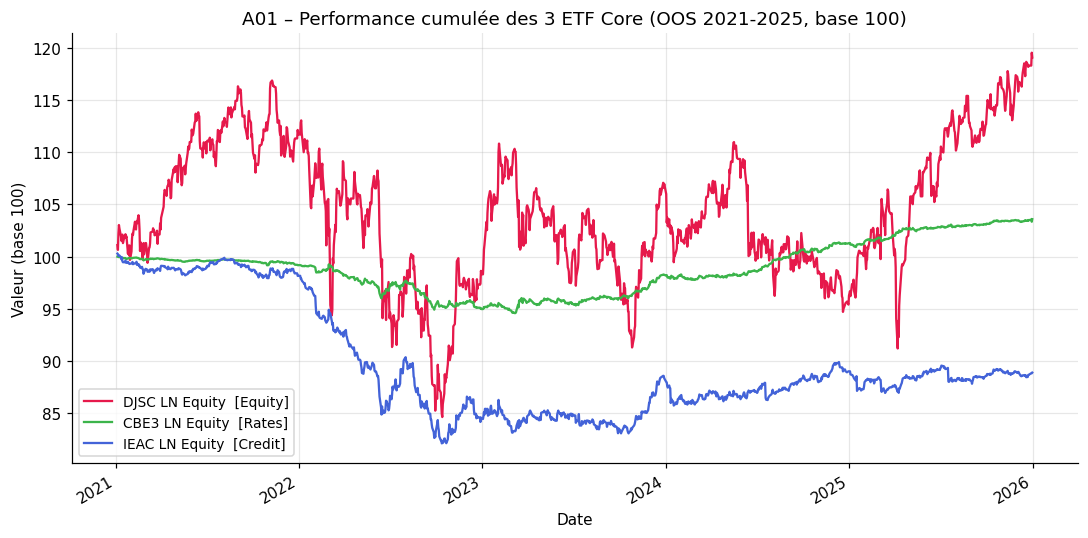

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\A01_core_etf_cum.png


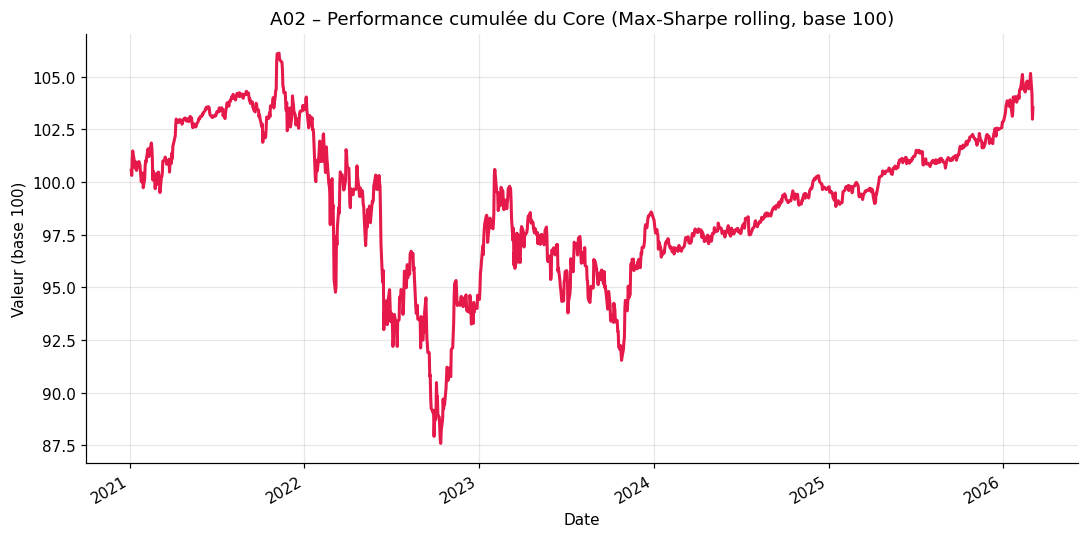

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\A02_core_portfolio_cum.png


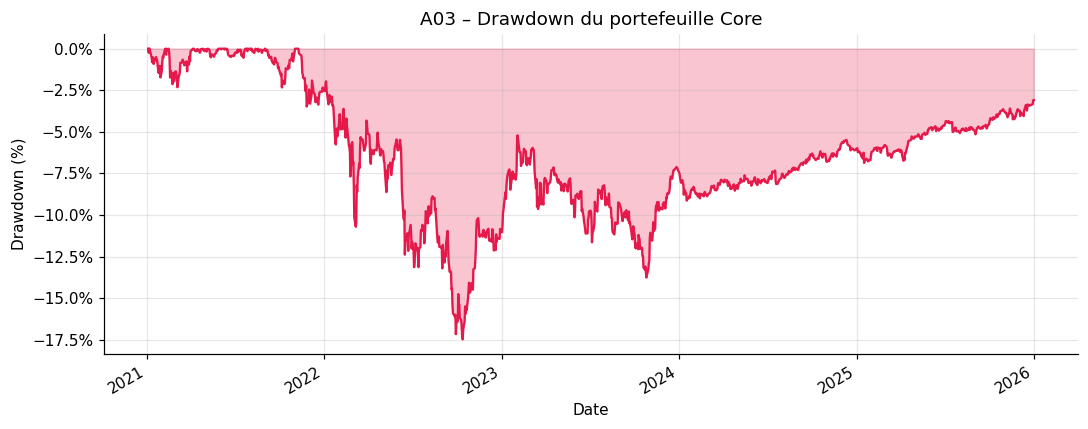

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\A03_core_drawdown.png


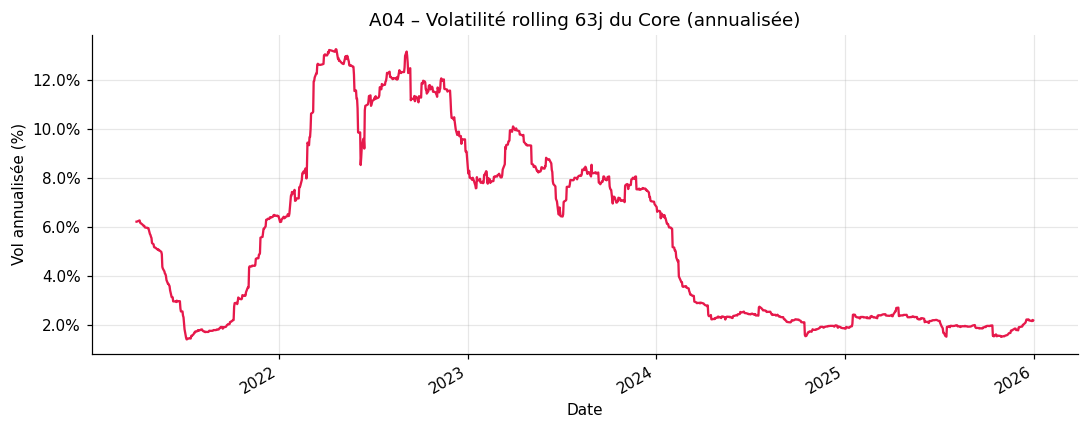

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\A04_core_rolling_vol.png


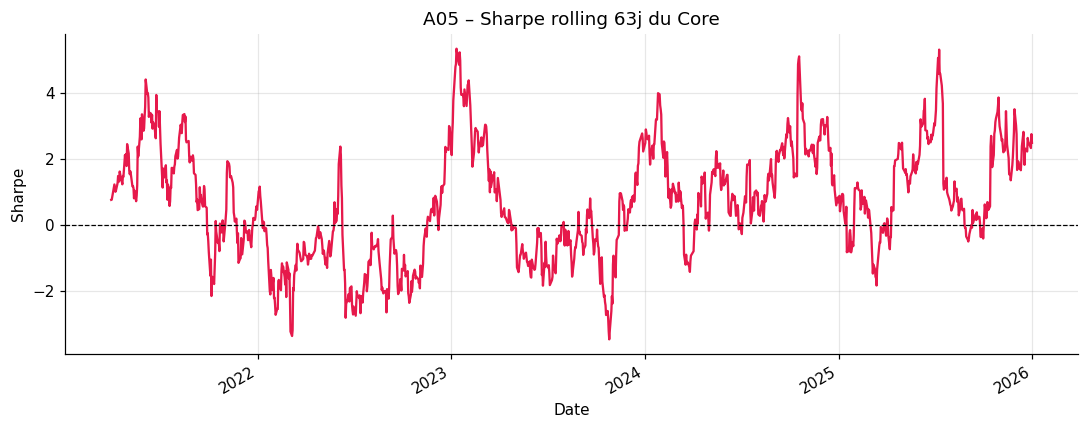

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\A05_core_rolling_sharpe.png


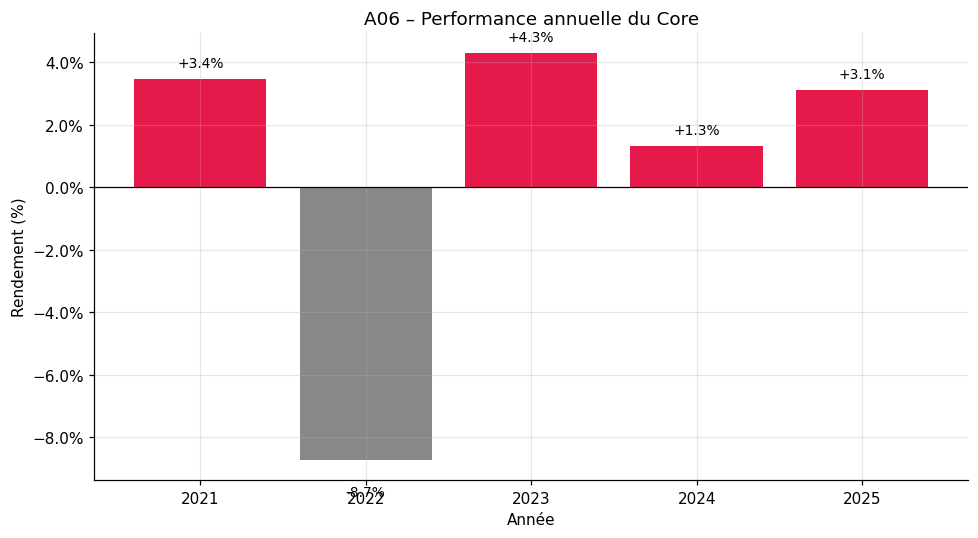

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\A06_core_annual_bar.png


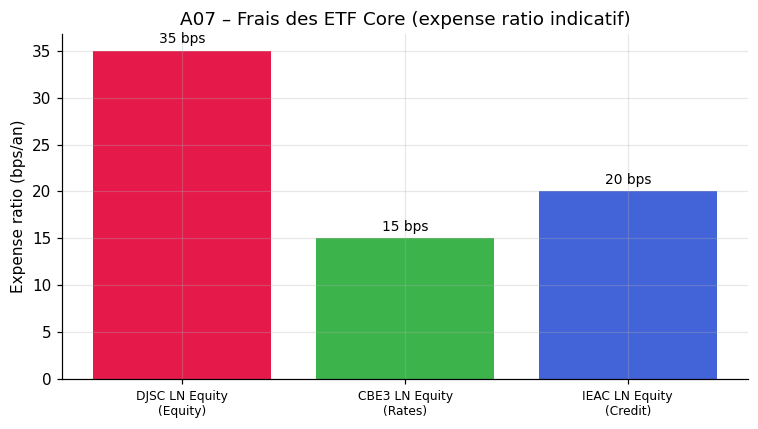

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\A07_core_fees_bar.png

[3] Section B – Poche Satellite (7 figures)...


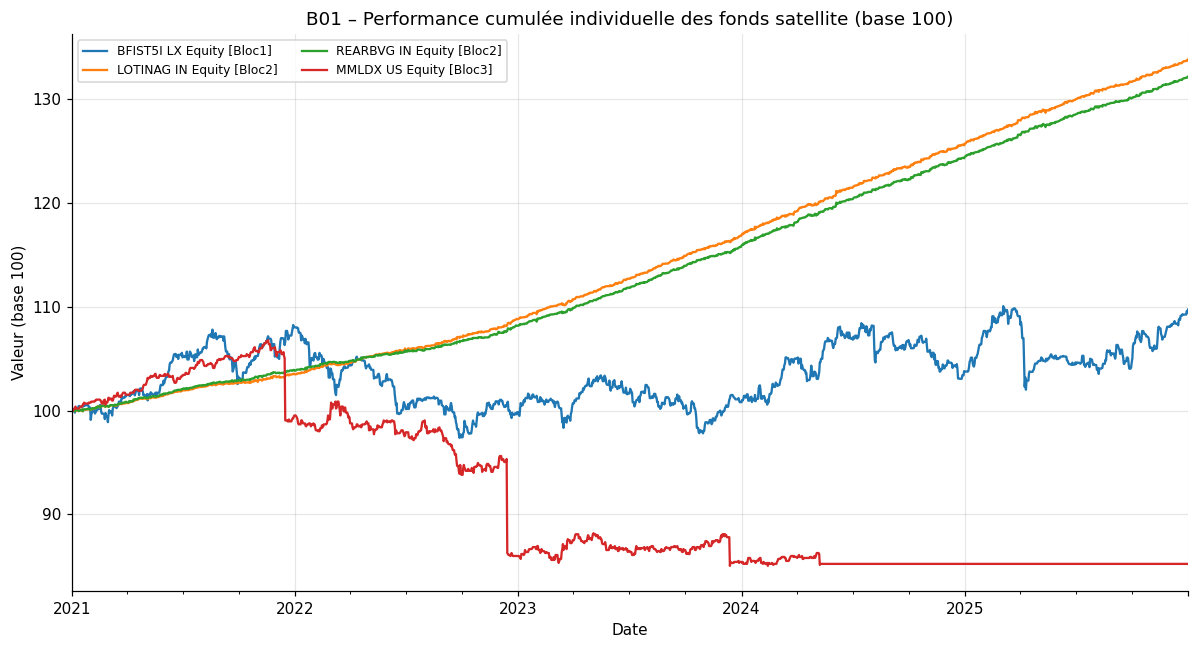

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\B01_sat_fund_cum.png


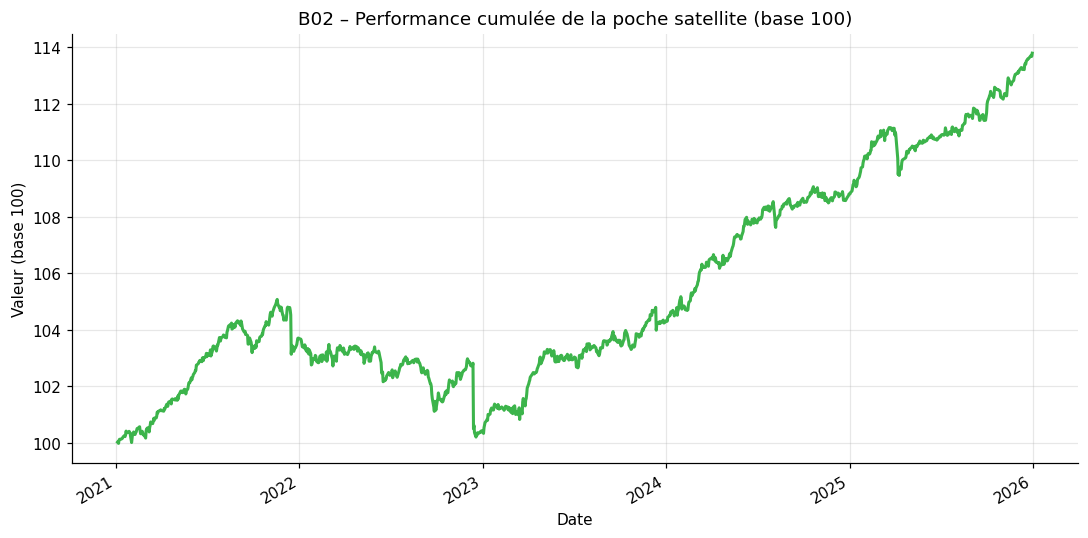

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\B02_sat_pocket_cum.png


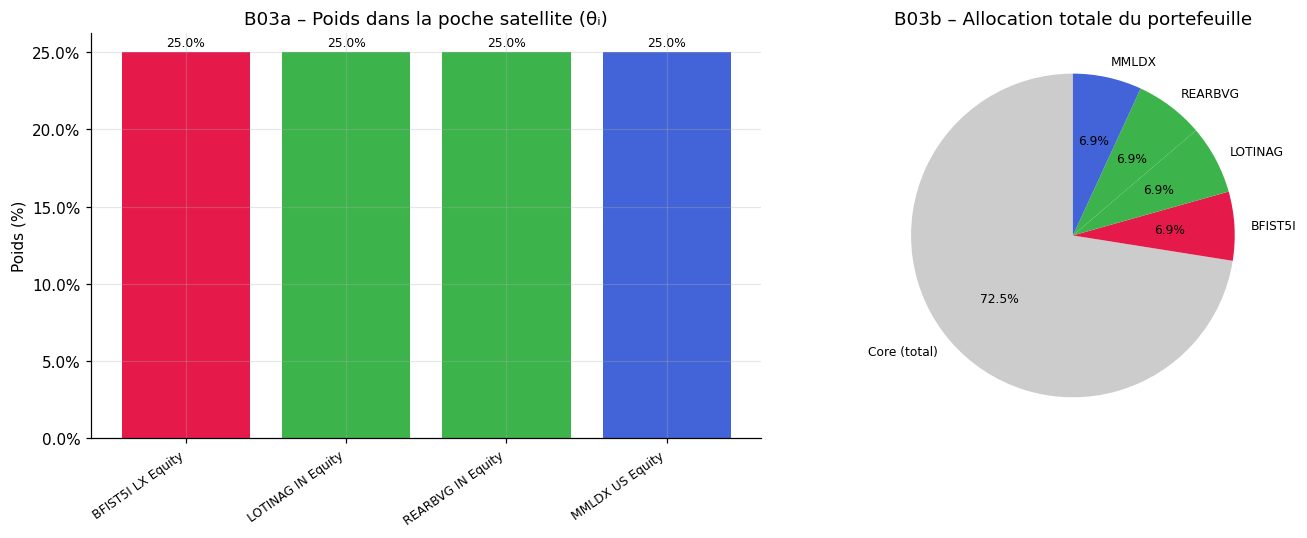

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\B03_sat_weights.png


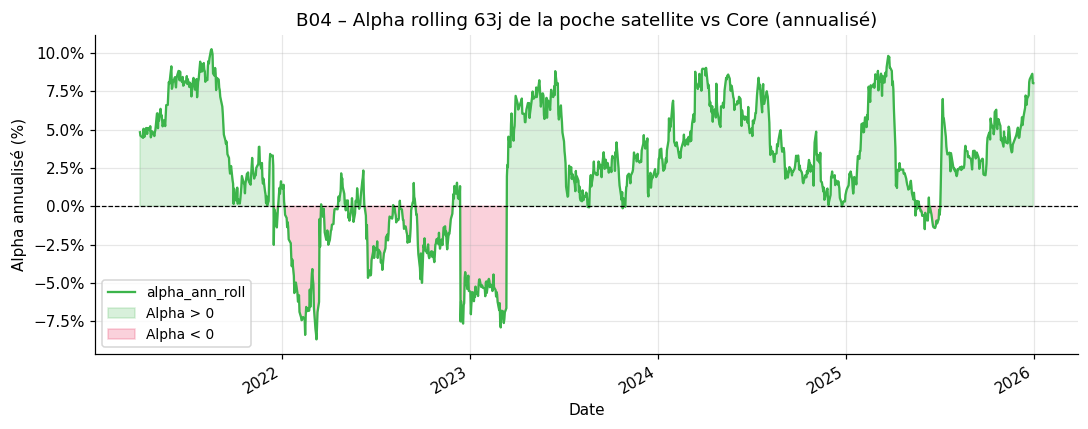

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\B04_sat_rolling_alpha.png


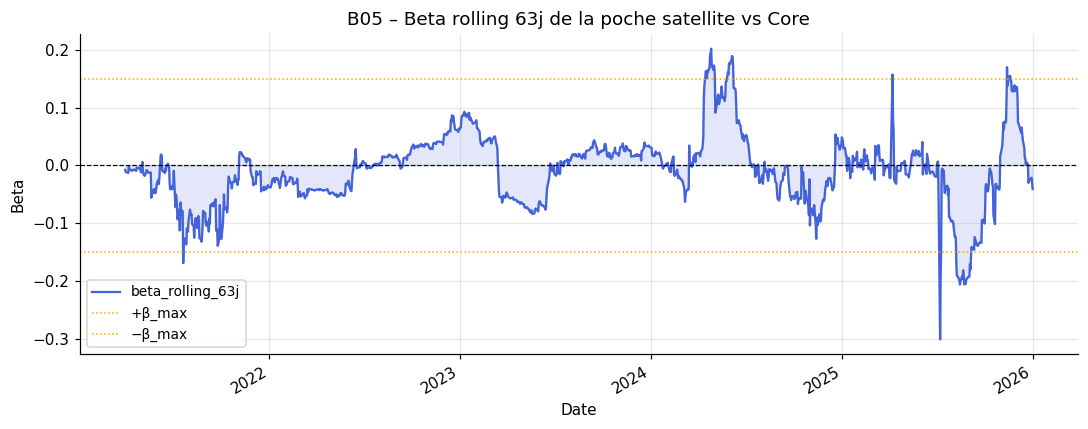

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\B05_sat_rolling_beta.png


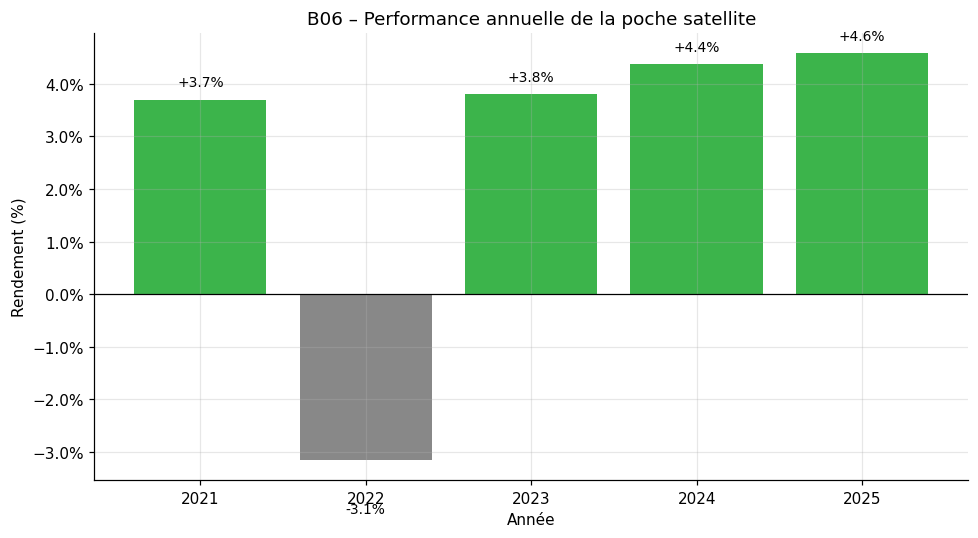

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\B06_sat_annual.png


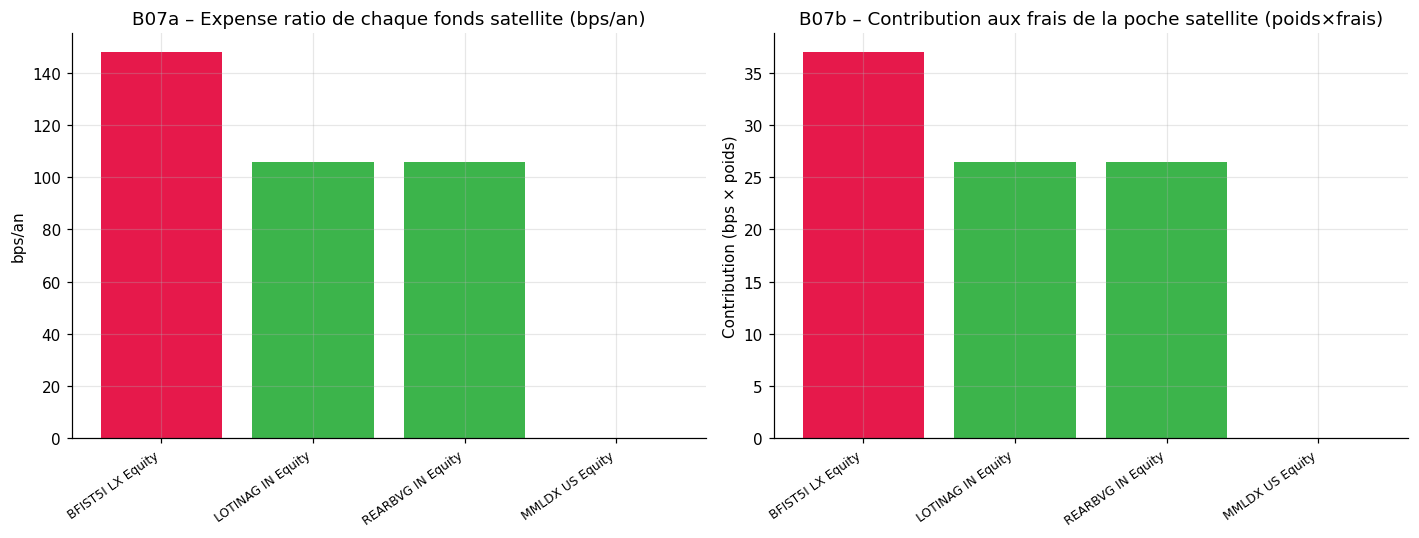

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\B07_sat_fees.png

[4] Section C – Core vs Satellite (4 figures)...


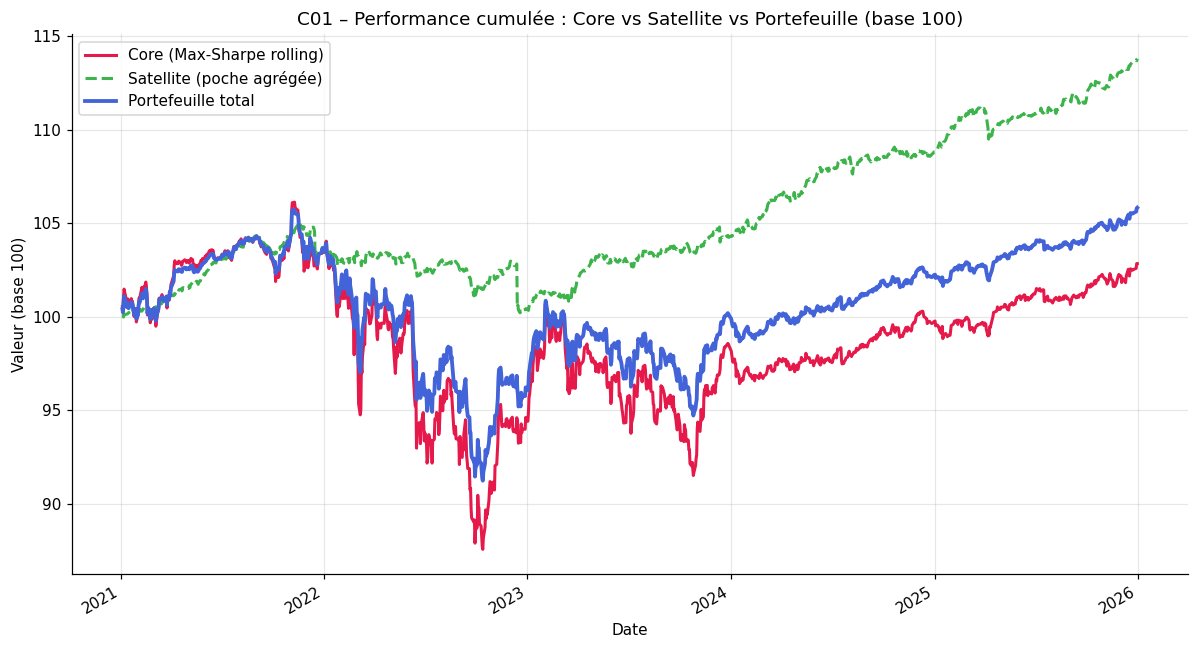

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\C01_core_vs_sat_cum.png


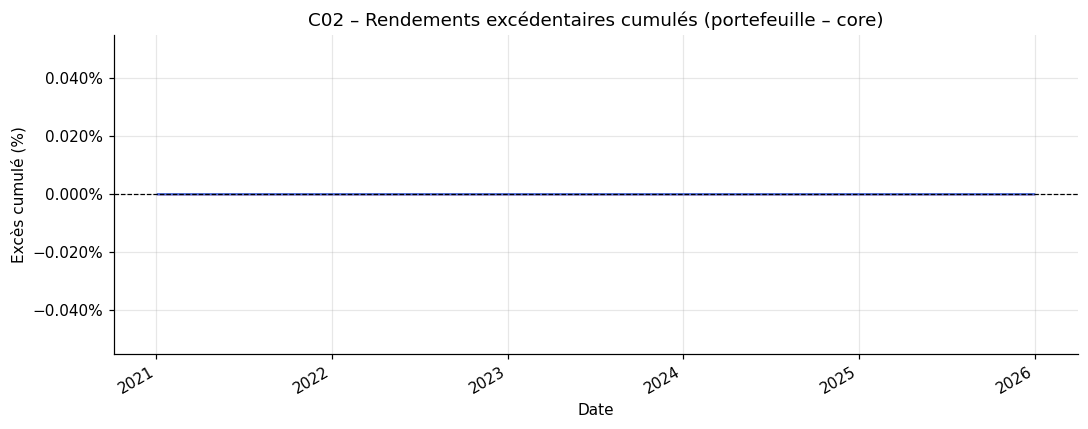

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\C02_excess_cum.png


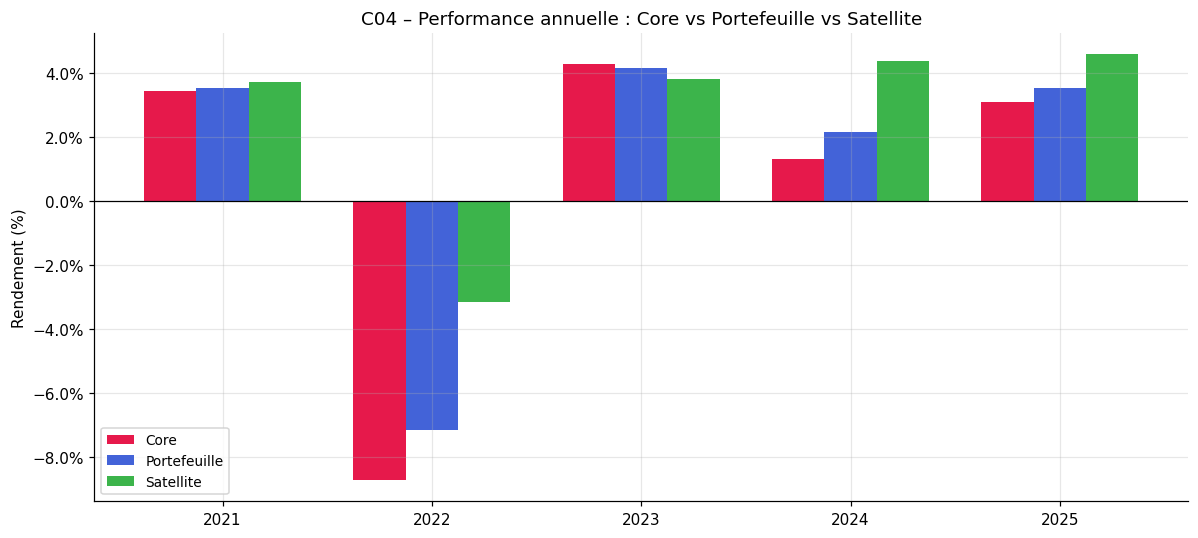

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\C04_annual_grouped_bar.png


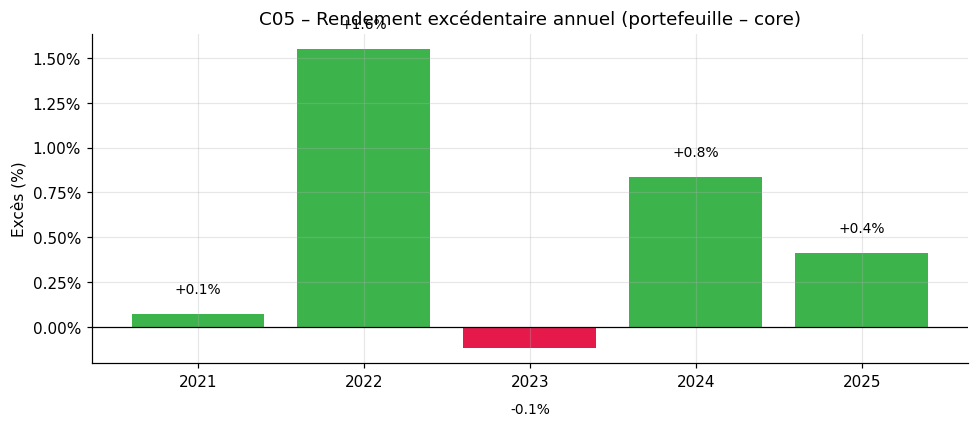

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\C05_excess_annual.png

[5] Section D – Portefeuille total (6 figures)...


c:\Users\33607\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


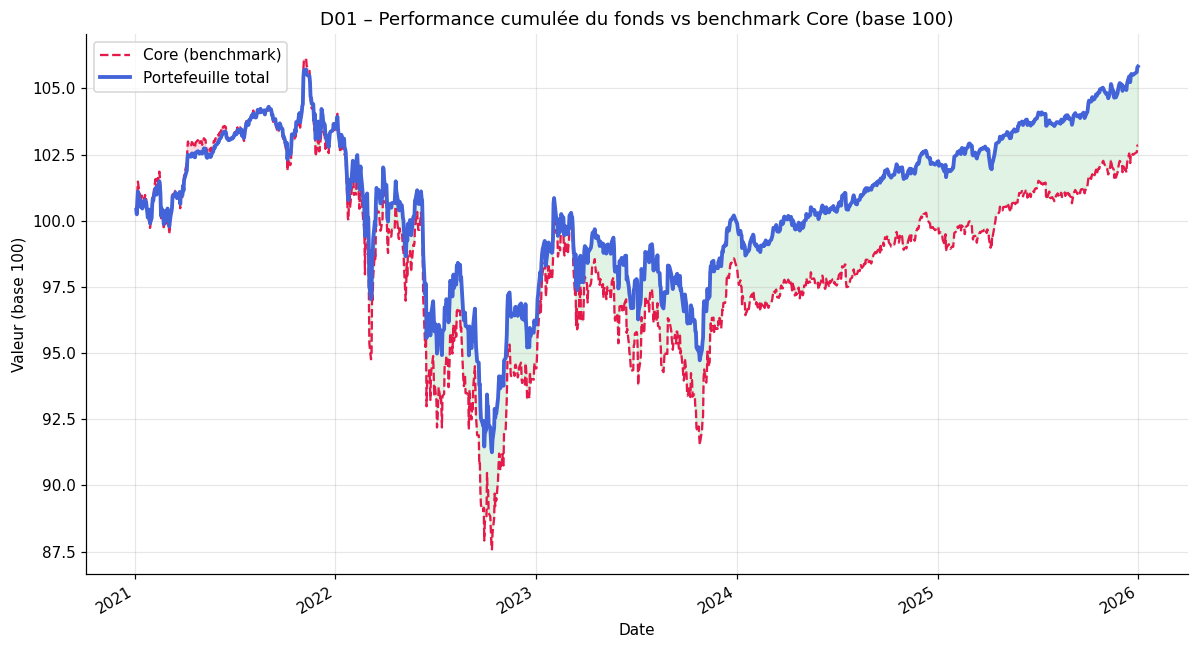

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\D01_portfolio_cum.png


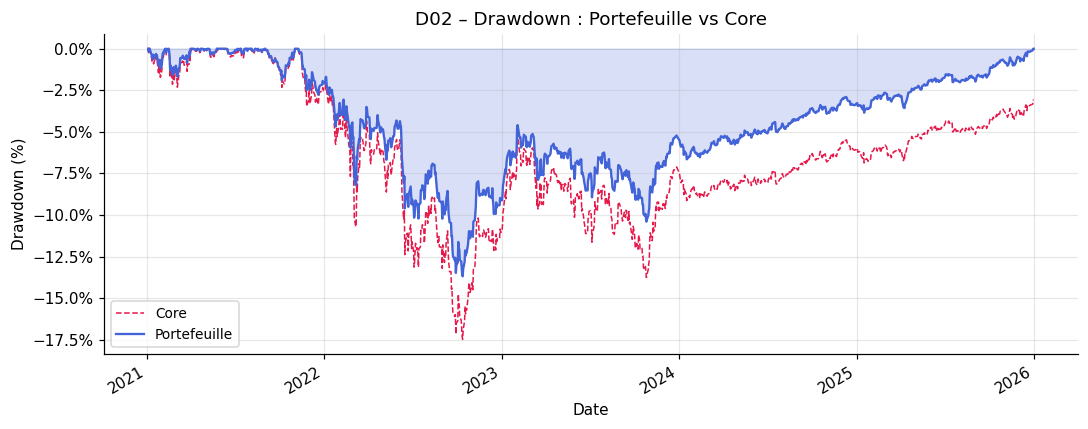

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\D02_portfolio_drawdown.png


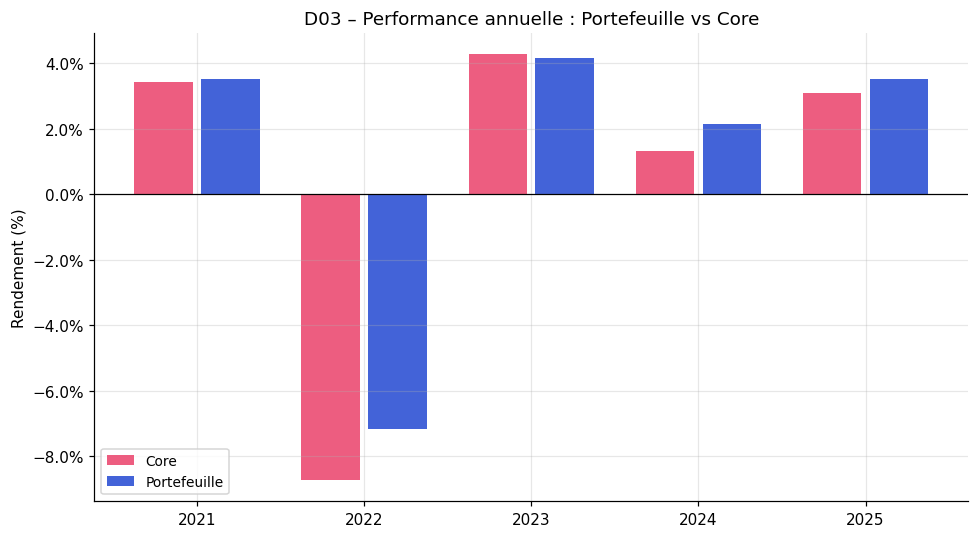

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\D03_portfolio_annual.png


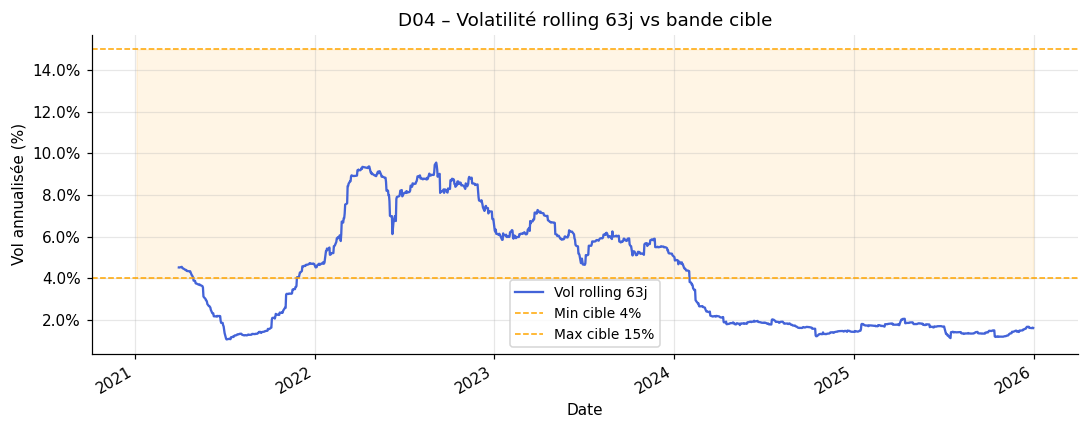

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\D04_portfolio_vol_target.png


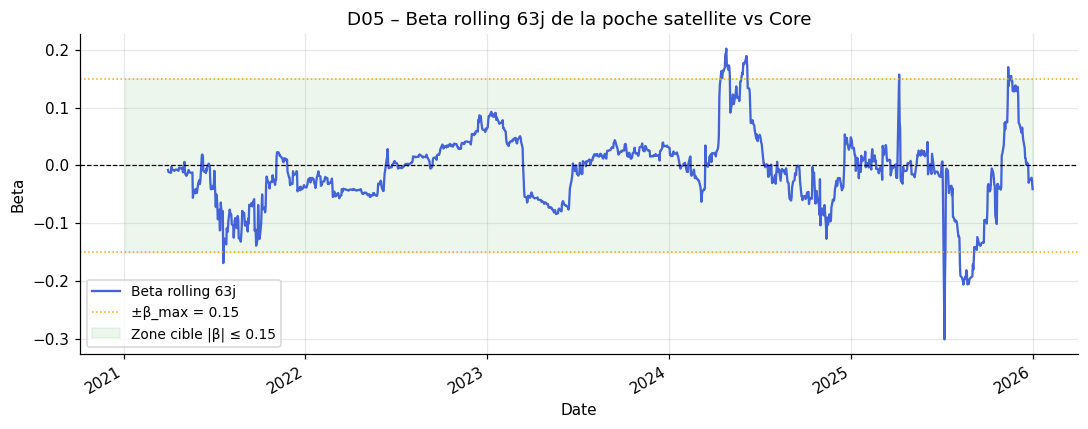

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\D05_beta_sat_rolling.png


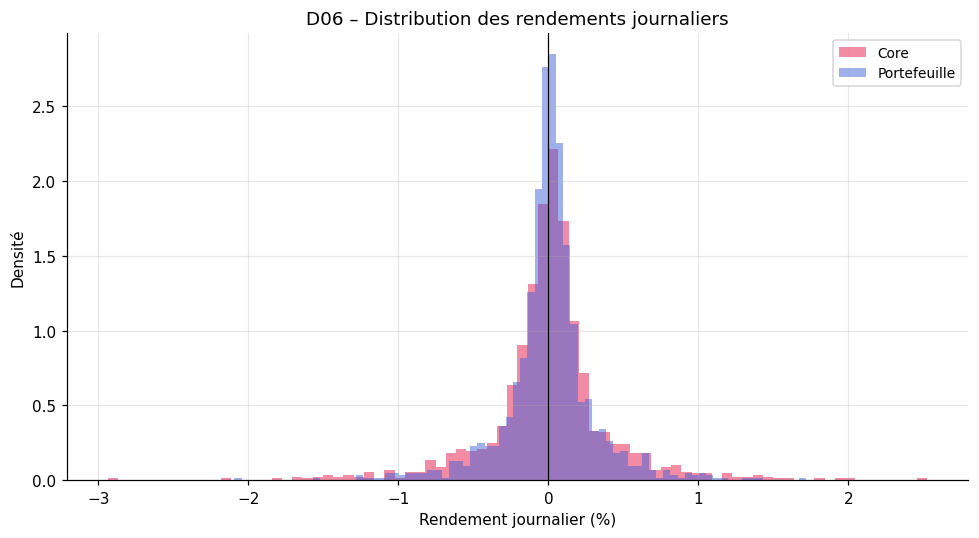

  -> C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures\D06_portfolio_dist.png

  ✓  24 figures générées dans C:\Users\33607\Desktop\M2 IEF\cross asset\Core_Satellite_Quant\outputs\figures


In [ ]:
from src.plots_report import main as plots_main
plots_main()

---
## Récapitulatif  Tableau de bord des métriques clés

Tableau synthétique IS vs OOS pour les 5 stratégies Core + le portefeuille total.

In [ ]:

# ── Comparaison des 5 stratégies Core ──────────────────────────────────────
comp = pd.read_csv('outputs/core_portfolio_comparison.csv', index_col=0)
rename = {
    'IS_ret_ann':  'Rdt IS',   'IS_vol_ann':  'Vol IS',   'IS_sharpe':   'Sharpe IS',
    'OOS_ret_ann': 'Rdt OOS',  'OOS_vol_ann': 'Vol OOS',  'OOS_sharpe':  'Sharpe OOS',
    'OOS_mdd':     'MDD OOS',
}
comp = comp.rename(columns=rename)
pct_cols = [c for c in comp.columns if c not in ['Sharpe IS', 'Sharpe OOS', 'poids']]
fmt = {c: '{:.1%}' for c in pct_cols}
fmt.update({'Sharpe IS': '{:.2f}', 'Sharpe OOS': '{:.2f}'})

print('=== Comparaison des 5 stratégies Core (IS 2019-2020 / OOS 2021-2025) ===')
display(comp.drop(columns=['poids'], errors='ignore').style.format(fmt)
        .highlight_max(subset=['Rdt OOS', 'Sharpe OOS'], color='lightgreen')
        .highlight_min(subset=['MDD OOS', 'Vol OOS'],    color='lightblue'))

# ── Métriques complètes du portefeuille global Core-Satellite ───────────────
m = pd.read_csv('outputs/fond_metrics.csv', index_col=0)

# --- Bloc 1 : Rendement / Risque / Drawdown ---------------------------------
perf_data = {
    'Rendement ann.':       (m.loc['ret_ann_portfolio',    m.columns[0]], True),
    'Volatilité ann.':      (m.loc['vol_portfolio_ann',    m.columns[0]], True),
    'Sharpe':               (m.loc['sharpe_portfolio',     m.columns[0]], False),
    'Max Drawdown':         (m.loc['max_drawdown',         m.columns[0]], True),
}
perf_df = pd.DataFrame({
    'Portefeuille total': {k: f"{v:.2%}" if pct else f"{v:.3f}" for k, (v, pct) in perf_data.items()},
    'Poche Core': {
        'Rendement ann.': f"{m.loc['ret_ann_core', m.columns[0]]:.2%}",
        'Volatilité ann.': f"{m.loc['vol_core_ann', m.columns[0]]:.2%}",
        'Sharpe': f"{m.loc['sharpe_core', m.columns[0]]:.3f}",
        'Max Drawdown': '—',
    },
    'Poche Satellite': {
        'Rendement ann.': f"{m.loc['ret_ann_satellite', m.columns[0]]:.2%}",
        'Volatilité ann.': f"{m.loc['vol_satellite_ann', m.columns[0]]:.2%}",
        'Sharpe': '—',
        'Max Drawdown': '—',
    },
})

print('\n\n=== TABLEAU DE BORD – Portefeuille Core-Satellite (OOS 2021-2025) ===\n')
print('── Rendement / Risque ──')
display(perf_df)

# --- Bloc 2 : Alpha / Beta vs Core -----------------------------------------
ab_data = {
    'Alpha (ann.) vs Core': f"{m.loc['alpha_portfolio_ann', m.columns[0]]:.2%}",
    'Beta vs Core':         f"{m.loc['beta_portfolio',      m.columns[0]]:.3f}",
}
ab_df = pd.DataFrame(ab_data, index=['Portefeuille']).T
ab_df.columns.name = ''
print('\n── Alpha / Beta vs Core ──')
display(ab_df)

# --- Bloc 3 : Satellite Beta -------------------------------------------------
beta_data = {
    'Alpha sat. ann. vs Core': f"{m.loc['alpha_satellite_ann', m.columns[0]]:.2%}",
    'Beta sat. statique':      f"{m.loc['beta_satellite_static', m.columns[0]]:.3f}",
    'Beta sat. rolling moy.':  f"{m.loc['beta_sat_rolling_mean', m.columns[0]]:.3f}",
    'Beta sat. rolling std.':  f"{m.loc['beta_sat_rolling_std',  m.columns[0]]:.3f}",
}
beta_df = pd.DataFrame(beta_data, index=['Satellite']).T
beta_df.columns.name = ''
print('\n── Satellite vs Core (bêta contrôlé ≤ 15%) ──')
display(beta_df)

# --- Bloc 4 : Allocation & Frais --------------------------------------------
alloc = {
    'w_core':  f"{m.loc['w_core', m.columns[0]]:.1%}",
    'w_sat':   f"{m.loc['w_sat',  m.columns[0]]:.1%}",
}
fees = {
    'Frais Core (contrib.)':     f"{m.loc['fees_core_contrib_bps', m.columns[0]]:.1f} bps",
    'Frais Sat. wavg.':          f"{m.loc['fees_sat_wavg_bps',     m.columns[0]]:.1f} bps",
    'Frais Sat. (contrib.)':     f"{m.loc['fees_sat_contrib_bps',  m.columns[0]]:.1f} bps",
    'Frais totaux portefeuille': f"{m.loc['fees_total_bps',        m.columns[0]]:.1f} bps",
    'Budget ≤ 80 bps':           '✓' if m.loc['fees_ok', m.columns[0]] else '✗',
}
af_df = pd.DataFrame({**alloc, **fees}, index=['Valeur']).T
af_df.columns.name = ''
print('\n── Allocation & Frais ──')
display(af_df)

# --- Bloc 5 : Performance annuelle ------------------------------------------
ann = pd.read_csv('outputs/fond_annual_perf.csv', index_col=0)
ann.index = ann.index.astype(int)
print('\n── Performance annuelle ──')
display(ann.style.format('{:.2%}')
        .applymap(lambda v: 'color: green' if v > 0 else 'color: red')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightyellow'))


=== Comparaison des 5 stratégies Core (IS 2019-2020 / OOS 2021-2025) ===


,Rdt IS,Vol IS,Sharpe IS,Rdt OOS,Vol OOS,Sharpe OOS,MDD OOS
strategie,,,,,,,
Max Sharpe,7.2%,9.5%,0.75,0.4%,7.3%,0.05,-20.4%
Min Variance,1.5%,2.6%,0.59,0.1%,2.2%,0.07,-9.0%
Equal Weight,5.6%,7.6%,0.74,0.9%,5.9%,0.15,-16.4%
Risk Parity,0.9%,1.7%,0.54,0.5%,1.8%,0.28,-7.1%
Max Sharpe Rolling,nan%,nan%,nan,0.9%,8.8%,0.10,-21.5%




=== TABLEAU DE BORD – Portefeuille Core-Satellite (OOS 2021-2025) ===

── Rendement / Risque ──


,Portefeuille total,Poche Core,Poche Satellite
Rendement ann.,1.12%,0.55%,2.57%
Volatilité ann.,4.83%,6.64%,2.05%
Sharpe,0.232,0.083,—
Max Drawdown,-13.68%,—,—



── Alpha / Beta vs Core ──


...


── Allocation & Frais ──


,Valeur
w_core,72.5%
w_sat,27.5%
Frais Core (contrib.),16.7 bps
Frais Sat. wavg.,90.0 bps
Frais Sat. (contrib.),24.8 bps
Frais totaux portefeuille,41.4 bps
Budget ≤ 80 bps,✓



── Performance annuelle ──


C:\Users\33607\AppData\Local\Temp\ipykernel_20584\3750557235.py:92: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: green' if v > 0 else 'color: red')


,portfolio,core,satellite
2021,3.51%,3.44%,3.70%
2022,-7.17%,-8.72%,-3.15%
2023,4.15%,4.27%,3.80%
2024,2.15%,1.31%,4.37%
2025,3.52%,3.10%,4.58%
